In [1]:
import pandas as pd
import numpy as np

In [2]:
df_customer = pd.read_csv(
    "data/Data_Customer.csv",
    low_memory=False
)
df_customer.head()

,CUSTOMER_NUMBER,CLIENT_SEX,CLIENT_CREATE_DATE,DATE_OF_BIRTH,STAFF_VIB,IB_REGISTER_DATE,EB_REGISTER_CHANNEL,SMS,VERIFY_METHOD
0,639362,M,2019-04-23,1996-01-01 00:00:00,N,2019-04-23,BRANCH,Y,SMS
1,452440,M,2019-01-11,1999-10-10 00:00:00,N,2019-01-11,BRANCH,Y,SMART_OTP
2,326290,F,2019-05-27,1996-06-29 00:00:00,N,2019-05-27,BRANCH,Y,SMS
3,20802,M,2019-11-12,1992-08-07 00:00:00,N,2019-11-12,BRANCH,Y,SMART_OTP
4,114244,M,2019-03-29,1973-10-15 00:00:00,N,2019-03-29,BRANCH,N,SMS


In [3]:
df_tx = pd.read_csv("data/Data_MyVIB_Transaction.csv")
df_tx.head()

,TRANS_LV1,TRANS_LV2,TRANS_DATE,DAY_OF_WEEK,TRANS_HOUR,TRANS_NO,TRANS_AMOUNT,CUSTOMER_NUMBER
0,Transfer,Outside_VIB,2019-01-03,Thu,17,2,189771864.0,701619
1,Transfer,Outside_VIB,2019-07-01,Mon,13,2,30224900.0,701619
2,Transfer,Outside_VIB,2019-01-02,Wed,15,1,100000.0,701619
3,Payment,Credit_card_repayment,2019-01-03,Thu,14,1,85000000.0,262123
4,Payment,Credit_card_repayment,2019-01-28,Mon,22,1,83000000.0,262123


In [4]:
tx_agg = (
    df_tx
    .groupby("CUSTOMER_NUMBER")
    .agg(
        tx_cnt=("TRANS_NO", "count"),
        tx_amount=("TRANS_AMOUNT", "sum"),
        transfer_cnt=("TRANS_LV1", lambda x: (x == "Transfer").sum()),
        payment_cnt=("TRANS_LV1", lambda x: (x == "Payment").sum())
    )
    .reset_index()
)

In [5]:
tx_agg.describe()

,CUSTOMER_NUMBER,tx_cnt,tx_amount,transfer_cnt,payment_cnt
count,52488.000000,52488.000000,5.248800e+04,52488.000000,52488.000000
mean,500866.791095,27.016270,2.369459e+08,18.858615,1.512974
std,288933.890054,52.063825,1.299664e+09,44.274183,6.985904
min,0.000000,1.000000,1.000000e+00,0.000000,0.000000
25%,250524.750000,3.000000,4.630800e+06,1.000000,0.000000
50%,502531.500000,10.000000,2.146271e+07,6.000000,0.000000
75%,751765.250000,30.000000,8.768225e+07,19.000000,1.000000
max,999982.000000,2622.000000,5.460931e+10,2622.000000,373.000000


In [6]:
df_act = pd.read_csv("data/Data_MyVIB_Activity.csv")
df_act.head()

,ACTIVITY_DATE,DAY_OF_WEEK,ACTIVITY_HOUR,ACTIVITY_NO,CUSTOMER_NUMBER,ACTIVITY_NAME
0,1/22/2019,Tue,20,2,630178,MB_INTEREST_RATE_VIEW
1,1/10/2019,Thu,18,16,630178,MB_INTEREST_RATE_VIEW
2,1/26/2019,Sat,17,15,630178,MB_INTEREST_RATE_VIEW
3,1/2/2019,Wed,9,27,630178,MB_INTEREST_RATE_VIEW
4,1/19/2019,Sat,8,3,630178,MB_INTEREST_RATE_VIEW


In [7]:
df_act["ACTIVITY_NAME"].value_counts().head(20)

ACTIVITY_NAME
LOGIN                          3638224
LOGOUT                         3499251
QUERY_ACCOUNT_INFORMATION      2566128
MB_INTEREST_RATE_VIEW          2448877
TRANSACTION_OVERVIEW_QUERY     1079162
LOGIN_FINGER                    784355
TRANSFER_VIA_SML                679219
LOGIN_FACEID                    237933
TRANSFER_VIB_ACCOUNT            216639
TOPUP_MOBILE                    206441
MB_LOCATION_POS_VIEW            184072
MB_ACCOUNT_QUICK_BALANCE        170850
AUTHENTICATION                  144475
MB_SET_PIN                       69744
MB_BILLPAY                       34703
TRANSFER_VIA_PAYMENT_CENTER      31443
MB_LOCATION_BRANCH_VIEW          28239
CHANGE_PASSWORD                  26410
TRANSFER_VIA_SML_ACCOUNT         20358
MB_LOCATION_ATM_VIEW             17996
Name: count, dtype: int64

In [8]:
#bảo vệ kiểu dữ liệu
df_act["ACTIVITY_NAME"] = df_act["ACTIVITY_NAME"].astype(str)
# tạo cờ nhóm transfer trên app
is_transfer = df_act["ACTIVITY_NAME"].str.startswith("TRANSFER_")
act_agg = (
    df_act
    .assign(is_transfer=is_transfer)
    .groupby("CUSTOMER_NUMBER")
    .agg(
        # A) volume
        activity_cnt=("ACTIVITY_NO", "count"),
        unique_activity_types=("ACTIVITY_NAME", "nunique"),

        # B) financial intents
        query_account_cnt=("ACTIVITY_NAME", lambda x: (x == "QUERY_ACCOUNT_INFORMATION").sum()),
        interest_rate_view_cnt=("ACTIVITY_NAME", lambda x: (x == "MB_INTEREST_RATE_VIEW").sum()),
        transaction_overview_cnt=("ACTIVITY_NAME", lambda x: (x == "TRANSACTION_OVERVIEW_QUERY").sum()),

        # C) digital transactions
        transfer_app_cnt=("is_transfer", "sum"),
        topup_mobile_cnt=("ACTIVITY_NAME", lambda x: (x == "TOPUP_MOBILE").sum()),
        billpay_cnt=("ACTIVITY_NAME", lambda x: (x == "MB_BILLPAY").sum()),

        # D) login/auth (optional)
        login_cnt=("ACTIVITY_NAME", lambda x: (x == "LOGIN").sum()),
        logout_cnt=("ACTIVITY_NAME", lambda x: (x == "LOGOUT").sum()),
        auth_cnt=("ACTIVITY_NAME", lambda x: (x == "AUTHENTICATION").sum()),
        login_finger_cnt=("ACTIVITY_NAME", lambda x: (x == "LOGIN_FINGER").sum()),
        login_faceid_cnt=("ACTIVITY_NAME", lambda x: (x == "LOGIN_FACEID").sum()),
    )
    .reset_index()
)

act_agg.head(), act_agg.describe()


(   CUSTOMER_NUMBER  activity_cnt  unique_activity_types  query_account_cnt  \
 0                0            63                      8                  7   
 1                3            69                      9                 14   
 2                9           189                     14                 36   
 3               13            13                      7                  2   
 4               15            58                     10                 10   
 
    interest_rate_view_cnt  transaction_overview_cnt  transfer_app_cnt  \
 0                       8                         4                10   
 1                      13                         1                 0   
 2                      38                        21                 2   
 3                       2                         1                 0   
 4                       9                         1                 3   
 
    topup_mobile_cnt  billpay_cnt  login_cnt  logout_cnt  auth_cnt  \
 0      

In [9]:
df_loan = pd.read_excel("data/Data_Lending.xlsx")

# đảm bảo numeric
for col in ["COUNT_OF_LOAN", "AVG_LOAN_AMOUNT"]:
    df_loan[col] = pd.to_numeric(df_loan[col], errors="coerce")

df_loan["loan_amount_est"] = df_loan["COUNT_OF_LOAN"] * df_loan["AVG_LOAN_AMOUNT"]

loan_agg = (
    df_loan
    .groupby("CUSTOMER_NUMBER")
    .agg(
        loan_cnt_total=("COUNT_OF_LOAN", "sum"),
        avg_loan_amount_mean=("AVG_LOAN_AMOUNT", "mean"),
        total_loan_est=("loan_amount_est", "sum"),
        active_loan_months=("MONTH", "nunique")
    )
    .reset_index()
)

loan_agg.head(), loan_agg.describe()


d:\DATN1\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
d:\DATN1\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


(   CUSTOMER_NUMBER  loan_cnt_total  avg_loan_amount_mean  total_loan_est  \
 0                7               6          2.730810e+08    1.638486e+09   
 1                8               7          3.026757e+07    2.118730e+08   
 2                9               3          1.541389e+09    4.624167e+09   
 3               14               5          1.483410e+07    7.417049e+07   
 4               16               8          1.490625e+09    1.192500e+10   
 
    active_loan_months  
 0                   6  
 1                   7  
 2                   3  
 3                   5  
 4                   4  ,
        CUSTOMER_NUMBER  loan_cnt_total  avg_loan_amount_mean  total_loan_est  \
 count    102014.000000   102014.000000          1.020140e+05    1.020140e+05   
 mean     500896.976807        6.405366          4.574846e+08    4.696369e+09   
 std      288174.133294        5.038756          1.326157e+09    2.906175e+11   
 min           7.000000        1.000000          7.000000e+02

In [10]:
df_dep = pd.read_csv("data/Data_Deposit.csv")
df_dep.head()
df_dep.columns

Index(['MONTH', 'COUNT_CA_ACCT', 'AVG_CA_BALANCE', 'COUNT_TD_ACCT',
       'AVG_TD_BALANCE', 'CUSTOMER_NUMBER'],
      dtype='str')

In [11]:
customer_behavior = (
    df_customer
    .merge(tx_agg, on="CUSTOMER_NUMBER", how="left")
    .merge(act_agg, on="CUSTOMER_NUMBER", how="left")
    .merge(loan_agg, on="CUSTOMER_NUMBER", how="left")
)

# chỉ fillna cho cột số để tránh lỗi với cột kiểu string
num_cols = customer_behavior.select_dtypes(include=[np.number]).columns
customer_behavior[num_cols] = customer_behavior[num_cols].fillna(0)
customer_behavior.shape, customer_behavior.head()


((290223, 30),
    CUSTOMER_NUMBER CLIENT_SEX CLIENT_CREATE_DATE        DATE_OF_BIRTH  \
 0           639362          M         2019-04-23  1996-01-01 00:00:00   
 1           452440          M         2019-01-11  1999-10-10 00:00:00   
 2           326290          F         2019-05-27  1996-06-29 00:00:00   
 3            20802          M         2019-11-12  1992-08-07 00:00:00   
 4           114244          M         2019-03-29  1973-10-15 00:00:00   
 
   STAFF_VIB IB_REGISTER_DATE EB_REGISTER_CHANNEL SMS VERIFY_METHOD  tx_cnt  \
 0         N       2019-04-23              BRANCH   Y           SMS    13.0   
 1         N       2019-01-11              BRANCH   Y     SMART_OTP     0.0   
 2         N       2019-05-27              BRANCH   Y           SMS    47.0   
 3         N       2019-11-12              BRANCH   Y     SMART_OTP     0.0   
 4         N       2019-03-29              BRANCH   N           SMS     0.0   
 
    ...  billpay_cnt  login_cnt  logout_cnt  auth_cnt  login_fi

In [12]:
df_dep = pd.read_csv("data/Data_Deposit.csv")
df_dep.head(), df_dep.columns

(       MONTH  COUNT_CA_ACCT  AVG_CA_BALANCE  COUNT_TD_ACCT  AVG_TD_BALANCE  \
 0  1/31/2019              1       246774.19              0             0.0   
 1  2/28/2019              1       209207.36              0             0.0   
 2  3/31/2019              1       213225.90              0             0.0   
 3  4/30/2019              1       211761.87              0             0.0   
 4  5/31/2019              1       222391.16              0             0.0   
 
    CUSTOMER_NUMBER  
 0           914393  
 1           914393  
 2           914393  
 3           914393  
 4           914393  ,
 Index(['MONTH', 'COUNT_CA_ACCT', 'AVG_CA_BALANCE', 'COUNT_TD_ACCT',
        'AVG_TD_BALANCE', 'CUSTOMER_NUMBER'],
       dtype='str'))

In [13]:
# đảm bảo numeric
for col in ["COUNT_CA_ACCT", "AVG_CA_BALANCE", "COUNT_TD_ACCT", "AVG_TD_BALANCE"]:
    df_dep[col] = pd.to_numeric(df_dep[col], errors="coerce")

dep_agg = (
    df_dep
    .groupby("CUSTOMER_NUMBER")
    .agg(
        # CASA
        ca_acct_cnt=("COUNT_CA_ACCT", "max"),
        avg_ca_balance=("AVG_CA_BALANCE", "mean"),

        # Term deposit
        td_acct_cnt=("COUNT_TD_ACCT", "max"),
        avg_td_balance=("AVG_TD_BALANCE", "mean"),

        # Tổng hợp
        deposit_active_months=("MONTH", "nunique")
    )
    .reset_index()
)

dep_agg.head(), dep_agg.describe()

(   CUSTOMER_NUMBER  ca_acct_cnt  avg_ca_balance  td_acct_cnt  avg_td_balance  \
 0                0            1    2.321421e+07            0    0.000000e+00   
 1                3            1    4.652719e+05            0    0.000000e+00   
 2                4            1    4.411876e+05            1    1.287097e+08   
 3                7            1    7.321123e+05            0    0.000000e+00   
 4                9            1    4.317109e+06            0    0.000000e+00   
 
    deposit_active_months  
 0                      4  
 1                      8  
 2                      5  
 3                      6  
 4                      3  ,
        CUSTOMER_NUMBER    ca_acct_cnt  avg_ca_balance    td_acct_cnt  \
 count    223817.000000  223817.000000    2.238170e+05  223817.000000   
 mean     500642.972875       0.940728    4.601295e+06       0.317152   
 std      288680.077364       0.280833    5.458864e+07       0.869103   
 min           0.000000       0.000000    0.000000e

In [14]:
customer_behavior = (
    customer_behavior
    .merge(dep_agg, on="CUSTOMER_NUMBER", how="left")
)

num_cols = customer_behavior.select_dtypes(include=[np.number]).columns
customer_behavior[num_cols] = customer_behavior[num_cols].fillna(0)
customer_behavior.shape


(290223, 35)

In [15]:
customer_behavior[[
    "tx_cnt",
    "activity_cnt",
    "loan_cnt_total",
    "avg_td_balance"
]].describe()


,tx_cnt,activity_cnt,loan_cnt_total,avg_td_balance
count,290223.000000,290223.000000,290223.000000,2.902230e+05
mean,4.886001,55.587169,2.251500,4.224536e+07
std,24.461230,201.629760,4.275127,3.762539e+08
min,0.000000,0.000000,0.000000,0.000000e+00
25%,0.000000,0.000000,0.000000,0.000000e+00
50%,0.000000,0.000000,0.000000,0.000000e+00
75%,0.000000,8.000000,3.000000,0.000000e+00
max,2622.000000,9435.000000,725.000000,1.079570e+11


In [16]:
cluster_features = [
    # Transaction
    "tx_cnt", "tx_amount", "transfer_cnt", "payment_cnt",

    # Digital banking
    "activity_cnt", "unique_activity_types",
    "transfer_app_cnt", "interest_rate_view_cnt",

    # Lending
    "loan_cnt_total", "total_loan_est",

    # Deposit
    "avg_ca_balance", "avg_td_balance",
    "ca_acct_cnt", "td_acct_cnt"
]


In [17]:
X = customer_behavior[cluster_features].copy()
X.describe()


,tx_cnt,tx_amount,transfer_cnt,payment_cnt,activity_cnt,unique_activity_types,transfer_app_cnt,interest_rate_view_cnt,loan_cnt_total,total_loan_est,avg_ca_balance,avg_td_balance,ca_acct_cnt,td_acct_cnt
count,290223.000000,2.902230e+05,290223.000000,290223.000000,290223.000000,290223.000000,290223.000000,290223.000000,290223.000000,2.902230e+05,2.902230e+05,2.902230e+05,290223.000000,290223.000000
mean,4.886001,4.285263e+07,3.410657,0.273628,55.587169,2.673902,3.265654,8.437915,2.251500,1.650784e+09,3.548471e+06,4.224536e+07,0.725480,0.244584
std,24.461230,5.601767e+08,20.179024,3.027404,201.629760,4.725022,18.882450,28.902140,4.275127,1.723142e+11,4.797726e+07,3.762539e+08,0.465811,0.774764
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
50%,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,2.090660e+05,0.000000e+00,1.000000,0.000000
75%,0.000000,0.000000e+00,0.000000,0.000000,8.000000,6.000000,0.000000,1.000000,3.000000,3.300000e+08,1.029060e+06,0.000000e+00,1.000000,0.000000
max,2622.000000,5.460931e+10,2622.000000,373.000000,9435.000000,25.000000,2351.000000,1821.000000,725.000000,9.203797e+13,1.730993e+10,1.079570e+11,10.000000,37.000000


In [18]:
import numpy as np

X_log = np.log1p(X)


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)


In [20]:
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
import joblib

# Fit models
kmeans = KMeans(n_clusters=4, random_state=42, n_init=100)
labels_kmeans = kmeans.fit_predict(X_scaled)

kmeans_pp = KMeans(
    n_clusters=4,
    init="k-means++",
    random_state=42,
    n_init=100
)
labels_kmeans_pp = kmeans_pp.fit_predict(X_scaled)

mini_kmeans = MiniBatchKMeans(
    n_clusters=4,
    batch_size=256,
    random_state=42,
    n_init=100
)
labels_mini = mini_kmeans.fit_predict(X_scaled)

# Gán vào DataFrame
customer_behavior["cluster"] = labels_kmeans
customer_behavior["cluster_kmeans_pp"] = labels_kmeans_pp
customer_behavior["cluster_mini_kmeans"] = labels_mini

In [21]:
customer_behavior[[
    "cluster",
    "cluster_kmeans_pp",
    "cluster_mini_kmeans"
]].head()

,cluster,cluster_kmeans_pp,cluster_mini_kmeans
0,2,2,1
1,1,1,3
2,2,2,1
3,3,3,0
4,1,1,2


In [22]:
score_kmeans = silhouette_score(X_scaled, labels_kmeans)
score_kmeans_pp = silhouette_score(X_scaled, labels_kmeans_pp)
score_mini = silhouette_score(X_scaled, labels_mini)

scores = {
    "KMeans": score_kmeans,
    "KMeans++": score_kmeans_pp,
    "MiniBatchKMeans": score_mini
}

for name, score in scores.items():
    print(f"{name}: {score:.4f}")

KMeans: 0.4422
KMeans++: 0.4422
MiniBatchKMeans: 0.4459


In [23]:
best_model_name = max(scores, key=scores.get)

if best_model_name == "KMeans":
    best_model = kmeans
    best_labels = labels_kmeans
elif best_model_name == "KMeans++":
    best_model = kmeans_pp
    best_labels = labels_kmeans_pp
else:
    best_model = mini_kmeans
    best_labels = labels_mini

print("Best model:", best_model_name)


Best model: MiniBatchKMeans


In [24]:
customer_behavior["cluster"] = best_labels
customer_behavior["cluster"].value_counts()

cluster
3    92252
0    81064
2    69380
1    47527
Name: count, dtype: int64

In [25]:
joblib.dump(best_model, "clustering_model.pkl")

['clustering_model.pkl']

In [26]:
loaded_model = joblib.load("clustering_model.pkl")

customer_behavior["cluster_loaded"] = loaded_model.predict(X_scaled)

In [27]:
cluster_profile = (
    customer_behavior
    .groupby("cluster")[cluster_features]
    .mean()
    .round(2)
)

cluster_profile


,tx_cnt,tx_amount,transfer_cnt,payment_cnt,activity_cnt,unique_activity_types,transfer_app_cnt,interest_rate_view_cnt,loan_cnt_total,total_loan_est,avg_ca_balance,avg_td_balance,ca_acct_cnt,td_acct_cnt
cluster,,,,,,,,,,,,,,
0,0.00,2.455699e+04,0.00,0.00,2.26,0.29,0.00,0.36,1.33,8.484743e+07,0.00,47125349.26,0.00,0.22
1,29.61,2.601156e+08,20.77,1.65,307.03,11.61,19.87,46.26,1.54,9.611353e+08,9831729.96,40761571.45,1.02,0.33
2,0.04,5.505913e+05,0.01,0.01,8.37,1.13,0.01,1.40,6.78,6.138678e+09,2616992.23,5061005.33,1.00,0.04
3,0.09,3.697566e+05,0.02,0.00,8.42,1.33,0.03,1.34,0.02,6.893958e+06,4130083.08,66686866.67,1.00,0.37


In [28]:
customer_behavior.groupby("cluster")[[
    "tx_cnt",
    "activity_cnt",
    "loan_cnt_total",
    "avg_td_balance"
]].median()


,tx_cnt,activity_cnt,loan_cnt_total,avg_td_balance
cluster,,,,
0,0.0,0.0,0.0,0.0
1,12.0,182.0,0.0,0.0
2,0.0,0.0,6.0,0.0
3,0.0,0.0,0.0,0.0


In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)


Explained variance ratio: [0.4794489  0.17665189]


In [30]:
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "KMeans": customer_behavior["cluster"],
    "KMeans++": customer_behavior["cluster_kmeans_pp"],
    "MiniBatch": customer_behavior["cluster_mini_kmeans"]
})


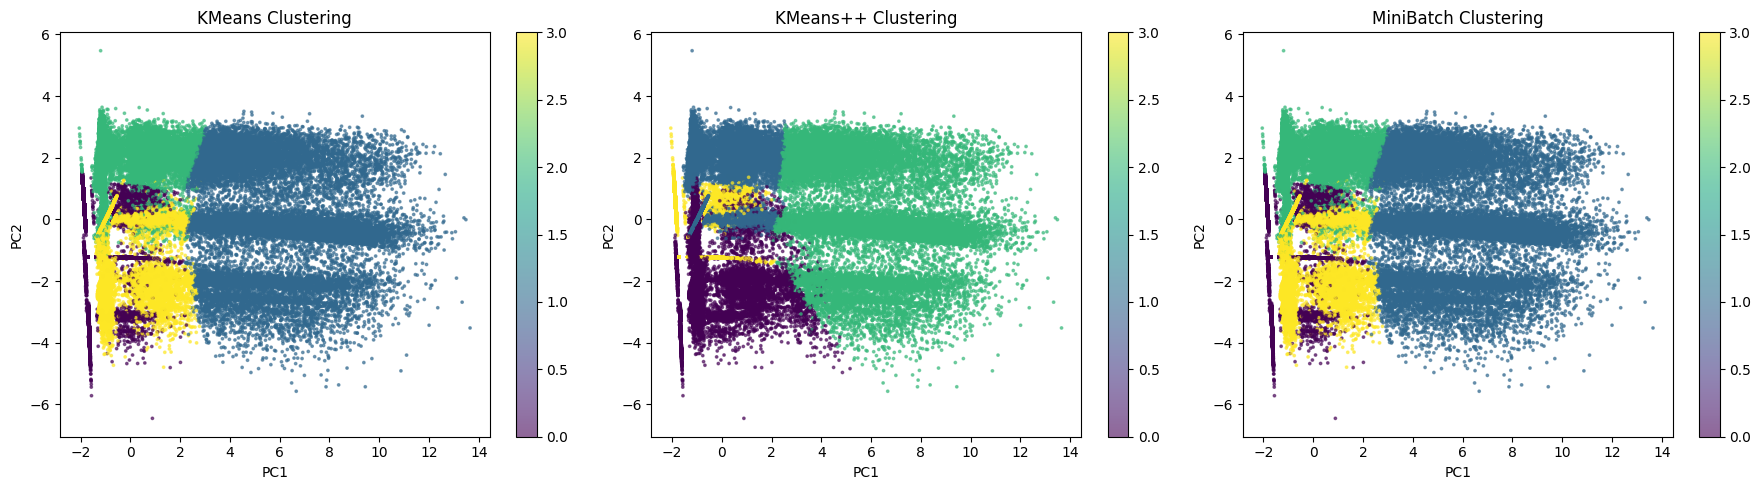

In [31]:
import matplotlib.pyplot as plt

models = ["KMeans", "KMeans++", "MiniBatch"]

plt.figure(figsize=(18, 5))

for i, model in enumerate(models, 1):
    plt.subplot(1, 3, i)
    scatter = plt.scatter(
        pca_df["PC1"],
        pca_df["PC2"],
        c=pca_df[model],
        s=3,
        alpha=0.6
    )
    plt.title(f"{model} Clustering")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.colorbar(scatter)

plt.tight_layout()
plt.show()


In [32]:
customer_behavior["cluster"].value_counts()

cluster
3    92252
0    81064
2    69380
1    47527
Name: count, dtype: int64

In [33]:
cluster_profile.shape
# (4, số_feature)

(4, 14)

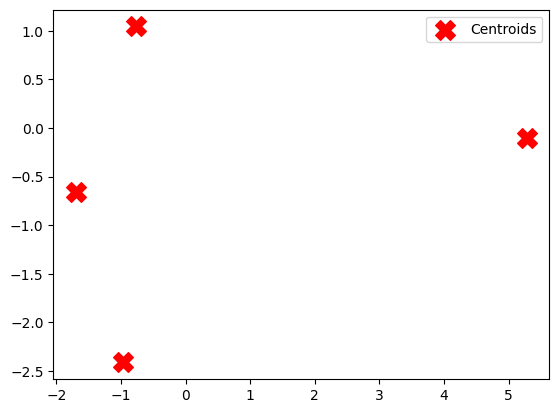

In [34]:
centers_pca = pca.transform(kmeans.cluster_centers_)

plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    c="red",
    s=200,
    marker="X",
    label="Centroids"
)
plt.legend()


In [35]:
import pandas as pd

with pd.ExcelWriter("clusters.xlsx") as writer:
    for c in customer_behavior["cluster"].unique():
        df_cluster = customer_behavior[customer_behavior["cluster"] == c]
        if not df_cluster.empty:
            df_cluster.to_excel(writer, sheet_name=f"cluster_{c}", index=False)

In [36]:
profile = customer_behavior.groupby("cluster")[
    [
        "tx_cnt", "transfer_cnt", "transfer_app_cnt",
        "loan_cnt_total", "total_loan_est",
        "avg_ca_balance", "avg_td_balance",
        "activity_cnt"
    ]
].mean().round(2)
print(profile)

         tx_cnt  transfer_cnt  transfer_app_cnt  loan_cnt_total  \
cluster                                                           
0          0.00          0.00              0.00            1.33   
1         29.61         20.77             19.87            1.54   
2          0.04          0.01              0.01            6.78   
3          0.09          0.02              0.03            0.02   

         total_loan_est  avg_ca_balance  avg_td_balance  activity_cnt  
cluster                                                                
0          8.484743e+07            0.00     47125349.26          2.26  
1          9.611353e+08      9831729.96     40761571.45        307.03  
2          6.138678e+09      2616992.23      5061005.33          8.37  
3          6.893958e+06      4130083.08     66686866.67          8.42  


In [37]:
import pandas as pd
import numpy as np

# 1) Load credit card data
df_card = pd.read_excel("data/Data_Card.xlsx", sheet_name="in")

# 2) Label: khách hàng đã từng có ít nhất 1 credit card?
card_label = (
    df_card.groupby("CUSTOMER_NUMBER")["COUNT_CREDITCARD"]
    .max()
    .gt(0)
    .astype(int)
    .rename("has_creditcard")
    .reset_index()
)

# 3) Merge vào bảng hành vi đã có cluster
df_cluster = customer_behavior.merge(card_label, on="CUSTOMER_NUMBER", how="left")
df_cluster["has_creditcard"] = df_cluster["has_creditcard"].fillna(0).astype(int)

df_cluster[["CUSTOMER_NUMBER","cluster","has_creditcard"]].head(), df_cluster["has_creditcard"].value_counts()

(   CUSTOMER_NUMBER  cluster  has_creditcard
 0           639362        1               0
 1           452440        3               0
 2           326290        1               0
 3            20802        0               0
 4           114244        2               0,
 has_creditcard
 0    247849
 1     42374
 Name: count, dtype: int64)

In [38]:
cluster_card = (
    df_cluster.groupby("cluster")["has_creditcard"]
    .agg(n_customers="count", n_has_card="sum", rate="mean")
    .reset_index()
)
cluster_card["rate_%"] = (cluster_card["rate"] * 100).round(2)
cluster_card.sort_values("rate_%", ascending=False)

,cluster,n_customers,n_has_card,rate,rate_%
0,0,81064,23893,0.294742,29.47
1,1,47527,7346,0.154565,15.46
2,2,69380,10211,0.147175,14.72
3,3,92252,924,0.010016,1.00


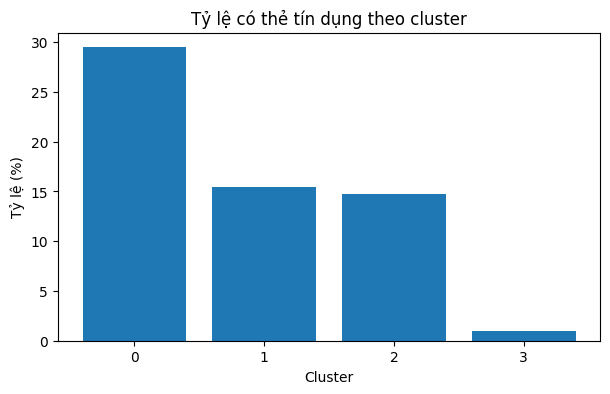

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.bar(cluster_card["cluster"].astype(str), cluster_card["rate_%"])
plt.title("Tỷ lệ có thẻ tín dụng theo cluster")
plt.xlabel("Cluster")
plt.ylabel("Tỷ lệ (%)")
plt.show()

In [40]:
from scipy.stats import chi2_contingency

ct = pd.crosstab(df_cluster["cluster"], df_cluster["has_creditcard"])
chi2, p, dof, exp = chi2_contingency(ct)

print("Contingency table:\n", ct)
print("Chi2:", chi2, "| dof:", dof, "| p-value:", p)

Contingency table:
 has_creditcard      0      1
cluster                     
0               57171  23893
1               40181   7346
2               59169  10211
3               91328    924
Chi2: 28093.891498816374 | dof: 3 | p-value: 0.0


In [41]:
from sklearn.model_selection import train_test_split

# Features giống phần clustering
base_features = cluster_features[:]  # tx/digital/loan/deposit

# X, y
X_base = df_cluster[base_features].copy()
y = df_cluster["has_creditcard"].astype(int)

# Chia train/test stratify
X_train, X_test, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, y_train.value_counts(normalize=True).round(3)

((232178, 14),
 has_creditcard
 0    0.854
 1    0.146
 Name: proportion, dtype: float64)

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

model_A = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

model_A.fit(X_train, y_train)

proba_A = model_A.predict_proba(X_test)[:, 1]
pred_A  = (proba_A >= 0.5).astype(int)

print("MODEL A (no cluster)")
print("ROC-AUC:", roc_auc_score(y_test, proba_A))
print("PR-AUC :", average_precision_score(y_test, proba_A))
print("Confusion:\n", confusion_matrix(y_test, pred_A))
print(classification_report(y_test, pred_A, digits=4))

MODEL A (no cluster)
ROC-AUC: 0.8772504220663487
PR-AUC : 0.6258698003362521
Confusion:
 [[33613 15957]
 [ 1368  7107]]
              precision    recall  f1-score   support

           0     0.9609    0.6781    0.7951     49570
           1     0.3081    0.8386    0.4507      8475

    accuracy                         0.7015     58045
   macro avg     0.6345    0.7583    0.6229     58045
weighted avg     0.8656    0.7015    0.7448     58045



In [43]:
# Thêm cluster vào feature set
X_plus = df_cluster[base_features + ["cluster"]].copy()

# split giống cách trên (để công bằng)
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_plus, y, test_size=0.2, random_state=42, stratify=y
)

# Pipeline: xử lý numeric + onehot cluster
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

num_cols = base_features
cat_cols = ["cluster"]

preprocess_B = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

model_B = Pipeline(steps=[
    ("preprocess", preprocess_B),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

model_B.fit(X2_train, y2_train)

proba_B = model_B.predict_proba(X2_test)[:, 1]
pred_B  = (proba_B >= 0.5).astype(int)

print("MODEL B (with cluster)")
print("ROC-AUC:", roc_auc_score(y2_test, proba_B))
print("PR-AUC :", average_precision_score(y2_test, proba_B))
print("Confusion:\n", confusion_matrix(y2_test, pred_B))
print(classification_report(y2_test, pred_B, digits=4))

MODEL B (with cluster)
ROC-AUC: 0.8798620311671526
PR-AUC : 0.6253345971426122
Confusion:
 [[33470 16100]
 [ 1334  7141]]
              precision    recall  f1-score   support

           0     0.9617    0.6752    0.7934     49570
           1     0.3073    0.8426    0.4503      8475

    accuracy                         0.6996     58045
   macro avg     0.6345    0.7589    0.6218     58045
weighted avg     0.8661    0.6996    0.7433     58045



In [44]:
auc_A = roc_auc_score(y_test, proba_A)
auc_B = roc_auc_score(y2_test, proba_B)

prauc_A = average_precision_score(y_test, proba_A)
prauc_B = average_precision_score(y2_test, proba_B)

print(f"AUC  Model A (no cluster) : {auc_A:.4f}")
print(f"AUC  Model B (with cluster): {auc_B:.4f}")
print(f"PR-AUC Model A             : {prauc_A:.4f}")
print(f"PR-AUC Model B             : {prauc_B:.4f}")

if auc_B > auc_A:
    print("✅ Model B tốt hơn → cluster giúp tăng khả năng dự báo mở thẻ.")
else:
    print("ℹ️ Model B không tốt hơn rõ rệt → cluster chủ yếu hữu ích cho diễn giải hành vi, không tăng dự báo nhiều.")

AUC  Model A (no cluster) : 0.8773
AUC  Model B (with cluster): 0.8799
PR-AUC Model A             : 0.6259
PR-AUC Model B             : 0.6253
✅ Model B tốt hơn → cluster giúp tăng khả năng dự báo mở thẻ.


In [45]:
from sklearn.inspection import permutation_importance

# dùng trên Model A để xem feature nào quan trọng
r = permutation_importance(model_A, X_test, y_test, n_repeats=10, random_state=42, scoring="roc_auc")

imp = pd.DataFrame({
    "feature": base_features,
    "importance": r.importances_mean
}).sort_values("importance", ascending=False)

imp.head(15)

,feature,importance
8,loan_cnt_total,0.241403
12,ca_acct_cnt,0.172625
5,unique_activity_types,0.039477
2,transfer_cnt,0.021418
0,tx_cnt,0.020357
3,payment_cnt,0.009324
6,transfer_app_cnt,0.008139
9,total_loan_est,0.002071
7,interest_rate_view_cnt,0.000494
10,avg_ca_balance,0.000095


In [46]:
# XGBOOST
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

# cân bằng lớp cho dữ liệu mất cân bằng
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos if pos > 0 else 1.0

model_xgb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=scale_pos_weight
    ))
])

model_xgb.fit(X_train, y_train)

proba_xgb = model_xgb.predict_proba(X_test)[:, 1]
pred_xgb = (proba_xgb >= 0.5).astype(int)

print("MODEL XGBOOST")
print("ROC-AUC:", roc_auc_score(y_test, proba_xgb))
print("PR-AUC :", average_precision_score(y_test, proba_xgb))
print("Confusion:\n", confusion_matrix(y_test, pred_xgb))
print(classification_report(y_test, pred_xgb, digits=4))

MODEL XGBOOST
ROC-AUC: 0.9426743314034621
PR-AUC : 0.8432264103993721
Confusion:
 [[46228  3342]
 [ 1741  6734]]
              precision    recall  f1-score   support

           0     0.9637    0.9326    0.9479     49570
           1     0.6683    0.7946    0.7260      8475

    accuracy                         0.9124     58045
   macro avg     0.8160    0.8636    0.8369     58045
weighted avg     0.9206    0.9124    0.9155     58045



In [47]:
# MODEL XGBOOST (with cluster)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

num_cols = base_features
cat_cols = ["cluster"]

preprocess_xgb = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

neg = (y2_train == 0).sum()
pos = (y2_train == 1).sum()
scale_pos_weight = neg / pos if pos > 0 else 1.0

model_xgb_cluster = Pipeline(steps=[
    ("preprocess", preprocess_xgb),
    ("clf", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=scale_pos_weight
    ))
])

model_xgb_cluster.fit(X2_train, y2_train)

proba_xgb_cluster = model_xgb_cluster.predict_proba(X2_test)[:, 1]
pred_xgb_cluster = (proba_xgb_cluster >= 0.5).astype(int)

print("MODEL XGBOOST (with cluster)")
print("ROC-AUC:", roc_auc_score(y2_test, proba_xgb_cluster))
print("PR-AUC :", average_precision_score(y2_test, proba_xgb_cluster))
print("Confusion:\n", confusion_matrix(y2_test, pred_xgb_cluster))
print(classification_report(y2_test, pred_xgb_cluster, digits=4))

MODEL XGBOOST (with cluster)
ROC-AUC: 0.9426902297814301
PR-AUC : 0.8430677627353473
Confusion:
 [[46188  3382]
 [ 1740  6735]]
              precision    recall  f1-score   support

           0     0.9637    0.9318    0.9475     49570
           1     0.6657    0.7947    0.7245      8475

    accuracy                         0.9118     58045
   macro avg     0.8147    0.8632    0.8360     58045
weighted avg     0.9202    0.9118    0.9149     58045



In [48]:
# RANDOM FOREST
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

model_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

model_rf.fit(X_train, y_train)

proba_rf = model_rf.predict_proba(X_test)[:, 1]
pred_rf = (proba_rf >= 0.5).astype(int)

print("MODEL RANDOM FOREST")
print("ROC-AUC:", roc_auc_score(y_test, proba_rf))
print("PR-AUC :", average_precision_score(y_test, proba_rf))
print("Confusion:\n", confusion_matrix(y_test, pred_rf))
print(classification_report(y_test, pred_rf, digits=4))

MODEL RANDOM FOREST
ROC-AUC: 0.9404553746288881
PR-AUC : 0.8391741740278372
Confusion:
 [[47559  2011]
 [ 2046  6429]]
              precision    recall  f1-score   support

           0     0.9588    0.9594    0.9591     49570
           1     0.7617    0.7586    0.7602      8475

    accuracy                         0.9301     58045
   macro avg     0.8602    0.8590    0.8596     58045
weighted avg     0.9300    0.9301    0.9300     58045



In [49]:
# MODEL RANDOM FOREST (with cluster)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

num_cols = base_features
cat_cols = ["cluster"]

preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

model_rf_cluster = Pipeline(steps=[
    ("preprocess", preprocess_rf),
    ("clf", RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

model_rf_cluster.fit(X2_train, y2_train)

proba_rf_cluster = model_rf_cluster.predict_proba(X2_test)[:, 1]
pred_rf_cluster = (proba_rf_cluster >= 0.5).astype(int)

print("MODEL RANDOM FOREST (with cluster)")
print("ROC-AUC:", roc_auc_score(y2_test, proba_rf_cluster))
print("PR-AUC :", average_precision_score(y2_test, proba_rf_cluster))
print("Confusion:\n", confusion_matrix(y2_test, pred_rf_cluster))
print(classification_report(y2_test, pred_rf_cluster, digits=4))

MODEL RANDOM FOREST (with cluster)
ROC-AUC: 0.9406861772303758
PR-AUC : 0.8392690733403401
Confusion:
 [[47553  2017]
 [ 2031  6444]]
              precision    recall  f1-score   support

           0     0.9590    0.9593    0.9592     49570
           1     0.7616    0.7604    0.7610      8475

    accuracy                         0.9303     58045
   macro avg     0.8603    0.8598    0.8601     58045
weighted avg     0.9302    0.9303    0.9302     58045



In [50]:
# DECISION TREE
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

model_dt = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", DecisionTreeClassifier(
        max_depth=6,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42
    ))
])

model_dt.fit(X_train, y_train)

proba_dt = model_dt.predict_proba(X_test)[:, 1]
pred_dt = (proba_dt >= 0.5).astype(int)

print("MODEL DECISION TREE")
print("ROC-AUC:", roc_auc_score(y_test, proba_dt))
print("PR-AUC :", average_precision_score(y_test, proba_dt))
print("Confusion:\n", confusion_matrix(y_test, pred_dt))
print(classification_report(y_test, pred_dt, digits=4))

MODEL DECISION TREE
ROC-AUC: 0.9379719356376343
PR-AUC : 0.816328972437994
Confusion:
 [[46512  3058]
 [ 1890  6585]]
              precision    recall  f1-score   support

           0     0.9610    0.9383    0.9495     49570
           1     0.6829    0.7770    0.7269      8475

    accuracy                         0.9148     58045
   macro avg     0.8219    0.8577    0.8382     58045
weighted avg     0.9204    0.9148    0.9170     58045



In [51]:
# MODEL DECISION TREE (with cluster)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

num_cols = base_features
cat_cols = ["cluster"]

preprocess_dt = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

model_dt_cluster = Pipeline(steps=[
    ("preprocess", preprocess_dt),
    ("clf", DecisionTreeClassifier(
        max_depth=6,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42
    ))
])

model_dt_cluster.fit(X2_train, y2_train)

proba_dt_cluster = model_dt_cluster.predict_proba(X2_test)[:, 1]
pred_dt_cluster = (proba_dt_cluster >= 0.5).astype(int)

print("MODEL DECISION TREE (with cluster)")
print("ROC-AUC:", roc_auc_score(y2_test, proba_dt_cluster))
print("PR-AUC :", average_precision_score(y2_test, proba_dt_cluster))
print("Confusion:\n", confusion_matrix(y2_test, pred_dt_cluster))
print(classification_report(y2_test, pred_dt_cluster, digits=4))

MODEL DECISION TREE (with cluster)
ROC-AUC: 0.9365985540545446
PR-AUC : 0.8084654233127347
Confusion:
 [[45347  4223]
 [ 1657  6818]]
              precision    recall  f1-score   support

           0     0.9647    0.9148    0.9391     49570
           1     0.6175    0.8045    0.6987      8475

    accuracy                         0.8987     58045
   macro avg     0.7911    0.8596    0.8189     58045
weighted avg     0.9140    0.8987    0.9040     58045



In [52]:
import pandas as pd
from sklearn.metrics import (
roc_auc_score, average_precision_score,
accuracy_score, precision_score, recall_score, f1_score
)

In [53]:
import pandas as pd
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score
)

required_vars = [
    "y_test", "y2_test",
    "proba_A", "pred_A", "proba_B", "pred_B",
    "proba_xgb", "pred_xgb", "proba_xgb_cluster", "pred_xgb_cluster",
    "proba_rf", "pred_rf", "proba_rf_cluster", "pred_rf_cluster",
    "proba_dt", "pred_dt", "proba_dt_cluster", "pred_dt_cluster"
]

missing = [v for v in required_vars if v not in globals()]
if missing:
    print("Thieu bien:", missing)
else:
    model_outputs = [
        ("Logistic_NoCluster", y_test, proba_A, pred_A),
        ("Logistic_WithCluster", y2_test, proba_B, pred_B),
        ("XGBoost_NoCluster", y_test, proba_xgb, pred_xgb),
        ("XGBoost_WithCluster", y2_test, proba_xgb_cluster, pred_xgb_cluster),
        ("RandomForest_NoCluster", y_test, proba_rf, pred_rf),
        ("RandomForest_WithCluster", y2_test, proba_rf_cluster, pred_rf_cluster),
        ("DecisionTree_NoCluster", y_test, proba_dt, pred_dt),
        ("DecisionTree_WithCluster", y2_test, proba_dt_cluster, pred_dt_cluster),
    ]

    rows = []
    for name, y_true, y_proba, y_pred in model_outputs:
        rows.append({
            "model": name,
            "roc_auc": roc_auc_score(y_true, y_proba),
            "pr_auc": average_precision_score(y_true, y_proba),
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
        })

    compare_df = (
        pd.DataFrame(rows)
        .sort_values(["roc_auc", "pr_auc"], ascending=False)
        .reset_index(drop=True)
    )

    display(compare_df.round(4))

,model,roc_auc,pr_auc,accuracy,precision,recall,f1
0,XGBoost_WithCluster,0.9427,0.8431,0.9118,0.6657,0.7947,0.7245
1,XGBoost_NoCluster,0.9427,0.8432,0.9124,0.6683,0.7946,0.7260
2,RandomForest_WithCluster,0.9407,0.8393,0.9303,0.7616,0.7604,0.7610
3,RandomForest_NoCluster,0.9405,0.8392,0.9301,0.7617,0.7586,0.7602
4,DecisionTree_NoCluster,0.9380,0.8163,0.9148,0.6829,0.7770,0.7269
5,DecisionTree_WithCluster,0.9366,0.8085,0.8987,0.6175,0.8045,0.6987
6,Logistic_WithCluster,0.8799,0.6253,0.6996,0.3073,0.8426,0.4503
7,Logistic_NoCluster,0.8773,0.6259,0.7015,0.3081,0.8386,0.4507


In [54]:
# ADASYN PREPROCESSING + APPLY TO ALL MODELS
from imblearn.over_sampling import ADASYN
import numpy as np

print("="*60)
print("ADASYN - Adaptive Synthetic Sampling")
print("="*60)

# Apply ADASYN to training data (no_cluster)
adasyn = ADASYN(random_state=42, n_neighbors=5)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

print(f"Original train shape: {X_train.shape}")
print(f"After ADASYN: {X_train_adasyn.shape}")
print(f"Class distribution: {np.bincount(y_train_adasyn)}")

# Logistic Regression with ADASYN
model_lr_adasyn = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])
model_lr_adasyn.fit(X_train_adasyn, y_train_adasyn)
proba_lr_adasyn = model_lr_adasyn.predict_proba(X_test)[:, 1]
pred_lr_adasyn = (proba_lr_adasyn >= 0.5).astype(int)

print("\n[LOGISTIC REGRESSION - ADASYN - No Cluster]")
print(f"ROC-AUC: {roc_auc_score(y_test, proba_lr_adasyn):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, proba_lr_adasyn):.4f}")
print(f"Accuracy: {accuracy_score(y_test, pred_lr_adasyn):.4f}")

# XGBoost with ADASYN
neg = (y_train_adasyn == 0).sum()
pos = (y_train_adasyn == 1).sum()
scale_pos_weight = neg / pos if pos > 0 else 1.0

model_xgb_adasyn = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, 
        objective="binary:logistic", eval_metric="logloss",
        random_state=42, scale_pos_weight=scale_pos_weight
    ))
])
model_xgb_adasyn.fit(X_train_adasyn, y_train_adasyn)
proba_xgb_adasyn = model_xgb_adasyn.predict_proba(X_test)[:, 1]
pred_xgb_adasyn = (proba_xgb_adasyn >= 0.5).astype(int)

print("\n[XGBoost - ADASYN - No Cluster]")
print(f"ROC-AUC: {roc_auc_score(y_test, proba_xgb_adasyn):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, proba_xgb_adasyn):.4f}")
print(f"Accuracy: {accuracy_score(y_test, pred_xgb_adasyn):.4f}")

# Random Forest with ADASYN
model_rf_adasyn = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=400, max_depth=None, min_samples_split=10,
        min_samples_leaf=5, class_weight="balanced", random_state=42, n_jobs=-1
    ))
])
model_rf_adasyn.fit(X_train_adasyn, y_train_adasyn)
proba_rf_adasyn = model_rf_adasyn.predict_proba(X_test)[:, 1]
pred_rf_adasyn = (proba_rf_adasyn >= 0.5).astype(int)

print("\n[RANDOM FOREST - ADASYN - No Cluster]")
print(f"ROC-AUC: {roc_auc_score(y_test, proba_rf_adasyn):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, proba_rf_adasyn):.4f}")
print(f"Accuracy: {accuracy_score(y_test, pred_rf_adasyn):.4f}")

# Decision Tree with ADASYN
model_dt_adasyn = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", DecisionTreeClassifier(
        max_depth=6, min_samples_split=20, min_samples_leaf=10,
        class_weight="balanced", random_state=42
    ))
])
model_dt_adasyn.fit(X_train_adasyn, y_train_adasyn)
proba_dt_adasyn = model_dt_adasyn.predict_proba(X_test)[:, 1]
pred_dt_adasyn = (proba_dt_adasyn >= 0.5).astype(int)

print("\n[DECISION TREE - ADASYN - No Cluster]")
print(f"ROC-AUC: {roc_auc_score(y_test, proba_dt_adasyn):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, proba_dt_adasyn):.4f}")
print(f"Accuracy: {accuracy_score(y_test, pred_dt_adasyn):.4f}")

ADASYN - Adaptive Synthetic Sampling
Original train shape: (232178, 14)
After ADASYN: (392747, 14)
Class distribution: [198279 194468]

[LOGISTIC REGRESSION - ADASYN - No Cluster]
ROC-AUC: 0.8780
PR-AUC: 0.6092
Accuracy: 0.6836

[XGBoost - ADASYN - No Cluster]
ROC-AUC: 0.9285
PR-AUC: 0.8043
Accuracy: 0.8115

[RANDOM FOREST - ADASYN - No Cluster]
ROC-AUC: 0.9296
PR-AUC: 0.8094
Accuracy: 0.8112

[DECISION TREE - ADASYN - No Cluster]
ROC-AUC: 0.9221
PR-AUC: 0.7697
Accuracy: 0.7622


In [55]:
# BORDERLINE-SMOTE PREPROCESSING + APPLY TO ALL MODELS
from imblearn.over_sampling import BorderlineSMOTE

print("="*60)
print("BORDERLINE-SMOTE")
print("="*60)

# Apply Borderline-SMOTE to training data
bsmote = BorderlineSMOTE(random_state=42, k_neighbors=5)
X_train_bsmote, y_train_bsmote = bsmote.fit_resample(X_train, y_train)

print(f"Original train shape: {X_train.shape}")
print(f"After Borderline-SMOTE: {X_train_bsmote.shape}")
print(f"Class distribution: {np.bincount(y_train_bsmote)}")

# Logistic Regression with Borderline-SMOTE
model_lr_bsmote = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])
model_lr_bsmote.fit(X_train_bsmote, y_train_bsmote)
proba_lr_bsmote = model_lr_bsmote.predict_proba(X_test)[:, 1]
pred_lr_bsmote = (proba_lr_bsmote >= 0.5).astype(int)

print("\n[LOGISTIC REGRESSION - Borderline-SMOTE - No Cluster]")
print(f"ROC-AUC: {roc_auc_score(y_test, proba_lr_bsmote):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, proba_lr_bsmote):.4f}")
print(f"Accuracy: {accuracy_score(y_test, pred_lr_bsmote):.4f}")

# XGBoost with Borderline-SMOTE
neg = (y_train_bsmote == 0).sum()
pos = (y_train_bsmote == 1).sum()
scale_pos_weight = neg / pos if pos > 0 else 1.0

model_xgb_bsmote = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        objective="binary:logistic", eval_metric="logloss",
        random_state=42, scale_pos_weight=scale_pos_weight
    ))
])
model_xgb_bsmote.fit(X_train_bsmote, y_train_bsmote)
proba_xgb_bsmote = model_xgb_bsmote.predict_proba(X_test)[:, 1]
pred_xgb_bsmote = (proba_xgb_bsmote >= 0.5).astype(int)

print("\n[XGBoost - Borderline-SMOTE - No Cluster]")
print(f"ROC-AUC: {roc_auc_score(y_test, proba_xgb_bsmote):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, proba_xgb_bsmote):.4f}")
print(f"Accuracy: {accuracy_score(y_test, pred_xgb_bsmote):.4f}")

# Random Forest with Borderline-SMOTE
model_rf_bsmote = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=400, max_depth=None, min_samples_split=10,
        min_samples_leaf=5, class_weight="balanced", random_state=42, n_jobs=-1
    ))
])
model_rf_bsmote.fit(X_train_bsmote, y_train_bsmote)
proba_rf_bsmote = model_rf_bsmote.predict_proba(X_test)[:, 1]
pred_rf_bsmote = (proba_rf_bsmote >= 0.5).astype(int)

print("\n[RANDOM FOREST - Borderline-SMOTE - No Cluster]")
print(f"ROC-AUC: {roc_auc_score(y_test, proba_rf_bsmote):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, proba_rf_bsmote):.4f}")
print(f"Accuracy: {accuracy_score(y_test, pred_rf_bsmote):.4f}")

# Decision Tree with Borderline-SMOTE
model_dt_bsmote = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", DecisionTreeClassifier(
        max_depth=6, min_samples_split=20, min_samples_leaf=10,
        class_weight="balanced", random_state=42
    ))
])
model_dt_bsmote.fit(X_train_bsmote, y_train_bsmote)
proba_dt_bsmote = model_dt_bsmote.predict_proba(X_test)[:, 1]
pred_dt_bsmote = (proba_dt_bsmote >= 0.5).astype(int)

print("\n[DECISION TREE - Borderline-SMOTE - No Cluster]")
print(f"ROC-AUC: {roc_auc_score(y_test, proba_dt_bsmote):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, proba_dt_bsmote):.4f}")
print(f"Accuracy: {accuracy_score(y_test, pred_dt_bsmote):.4f}")

BORDERLINE-SMOTE
Original train shape: (232178, 14)
After Borderline-SMOTE: (396558, 14)
Class distribution: [198279 198279]

[LOGISTIC REGRESSION - Borderline-SMOTE - No Cluster]
ROC-AUC: 0.8595
PR-AUC: 0.5238
Accuracy: 0.8338

[XGBoost - Borderline-SMOTE - No Cluster]
ROC-AUC: 0.9355
PR-AUC: 0.8339
Accuracy: 0.9343

[RANDOM FOREST - Borderline-SMOTE - No Cluster]
ROC-AUC: 0.9349
PR-AUC: 0.8355
Accuracy: 0.9336

[DECISION TREE - Borderline-SMOTE - No Cluster]
ROC-AUC: 0.9238
PR-AUC: 0.7739
Accuracy: 0.8794


In [56]:
# RANDOM OVERSAMPLER PREPROCESSING + APPLY TO ALL MODELS
from imblearn.over_sampling import RandomOverSampler

print("="*60)
print("RANDOM OVERSAMPLER")
print("="*60)

# Apply Random OverSampler to training data
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

print(f"Original train shape: {X_train.shape}")
print(f"After RandomOverSampler: {X_train_ros.shape}")
print(f"Class distribution: {np.bincount(y_train_ros)}")

# Logistic Regression with RandomOverSampler
model_lr_ros = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])
model_lr_ros.fit(X_train_ros, y_train_ros)
proba_lr_ros = model_lr_ros.predict_proba(X_test)[:, 1]
pred_lr_ros = (proba_lr_ros >= 0.5).astype(int)

print("\n[LOGISTIC REGRESSION - RandomOverSampler - No Cluster]")
print(f"ROC-AUC: {roc_auc_score(y_test, proba_lr_ros):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, proba_lr_ros):.4f}")
print(f"Accuracy: {accuracy_score(y_test, pred_lr_ros):.4f}")

# XGBoost with RandomOverSampler
neg = (y_train_ros == 0).sum()
pos = (y_train_ros == 1).sum()
scale_pos_weight = neg / pos if pos > 0 else 1.0

model_xgb_ros = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        objective="binary:logistic", eval_metric="logloss",
        random_state=42, scale_pos_weight=scale_pos_weight
    ))
])
model_xgb_ros.fit(X_train_ros, y_train_ros)
proba_xgb_ros = model_xgb_ros.predict_proba(X_test)[:, 1]
pred_xgb_ros = (proba_xgb_ros >= 0.5).astype(int)

print("\n[XGBoost - RandomOverSampler - No Cluster]")
print(f"ROC-AUC: {roc_auc_score(y_test, proba_xgb_ros):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, proba_xgb_ros):.4f}")
print(f"Accuracy: {accuracy_score(y_test, pred_xgb_ros):.4f}")

# Random Forest with RandomOverSampler
model_rf_ros = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=400, max_depth=None, min_samples_split=10,
        min_samples_leaf=5, class_weight="balanced", random_state=42, n_jobs=-1
    ))
])
model_rf_ros.fit(X_train_ros, y_train_ros)
proba_rf_ros = model_rf_ros.predict_proba(X_test)[:, 1]
pred_rf_ros = (proba_rf_ros >= 0.5).astype(int)

print("\n[RANDOM FOREST - RandomOverSampler - No Cluster]")
print(f"ROC-AUC: {roc_auc_score(y_test, proba_rf_ros):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, proba_rf_ros):.4f}")
print(f"Accuracy: {accuracy_score(y_test, pred_rf_ros):.4f}")

# Decision Tree with RandomOverSampler
model_dt_ros = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", DecisionTreeClassifier(
        max_depth=6, min_samples_split=20, min_samples_leaf=10,
        class_weight="balanced", random_state=42
    ))
])
model_dt_ros.fit(X_train_ros, y_train_ros)
proba_dt_ros = model_dt_ros.predict_proba(X_test)[:, 1]
pred_dt_ros = (proba_dt_ros >= 0.5).astype(int)

print("\n[DECISION TREE - RandomOverSampler - No Cluster]")
print(f"ROC-AUC: {roc_auc_score(y_test, proba_dt_ros):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, proba_dt_ros):.4f}")
print(f"Accuracy: {accuracy_score(y_test, pred_dt_ros):.4f}")

RANDOM OVERSAMPLER
Original train shape: (232178, 14)
After RandomOverSampler: (396558, 14)
Class distribution: [198279 198279]

[LOGISTIC REGRESSION - RandomOverSampler - No Cluster]
ROC-AUC: 0.8771
PR-AUC: 0.6266
Accuracy: 0.7017

[XGBoost - RandomOverSampler - No Cluster]
ROC-AUC: 0.9427
PR-AUC: 0.8436
Accuracy: 0.9123

[RANDOM FOREST - RandomOverSampler - No Cluster]
ROC-AUC: 0.9398
PR-AUC: 0.8367
Accuracy: 0.9289

[DECISION TREE - RandomOverSampler - No Cluster]
ROC-AUC: 0.9378
PR-AUC: 0.8161
Accuracy: 0.9149


In [57]:
# SO SÁNH TẤT CẢ CÁC KỸ THUẬT XỬ LÝ MẤT CÂN BẰNG
comparison_resampling = []

# No Cluster Models
techniques_no_cluster = [
    ("Logistic_ADASYN", y_test, proba_lr_adasyn, pred_lr_adasyn),
    ("Logistic_Borderline-SMOTE", y_test, proba_lr_bsmote, pred_lr_bsmote),
    ("Logistic_RandomOS", y_test, proba_lr_ros, pred_lr_ros),
    ("XGBoost_ADASYN", y_test, proba_xgb_adasyn, pred_xgb_adasyn),
    ("XGBoost_Borderline-SMOTE", y_test, proba_xgb_bsmote, pred_xgb_bsmote),
    ("XGBoost_RandomOS", y_test, proba_xgb_ros, pred_xgb_ros),
    ("RF_ADASYN", y_test, proba_rf_adasyn, pred_rf_adasyn),
    ("RF_Borderline-SMOTE", y_test, proba_rf_bsmote, pred_rf_bsmote),
    ("RF_RandomOS", y_test, proba_rf_ros, pred_rf_ros),
    ("DT_ADASYN", y_test, proba_dt_adasyn, pred_dt_adasyn),
    ("DT_Borderline-SMOTE", y_test, proba_dt_bsmote, pred_dt_bsmote),
    ("DT_RandomOS", y_test, proba_dt_ros, pred_dt_ros),
]

for name, y_true, y_proba, y_pred in techniques_no_cluster:
    comparison_resampling.append({
        "Technique": name,
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    })

comparison_df = pd.DataFrame(comparison_resampling).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
print(comparison_df.round(4))

                    Technique  ROC-AUC  PR-AUC  Accuracy  Precision  Recall  \
0            XGBoost_RandomOS   0.9427  0.8436    0.9123     0.6680  0.7945   
1                 RF_RandomOS   0.9398  0.8367    0.9289     0.7555  0.7586   
2                 DT_RandomOS   0.9378  0.8161    0.9149     0.6838  0.7762   
3    XGBoost_Borderline-SMOTE   0.9355  0.8339    0.9343     0.8018  0.7310   
4         RF_Borderline-SMOTE   0.9349  0.8355    0.9336     0.7923  0.7386   
5                   RF_ADASYN   0.9296  0.8094    0.8112     0.4240  0.8170   
6              XGBoost_ADASYN   0.9285  0.8043    0.8115     0.4239  0.8113   
7         DT_Borderline-SMOTE   0.9238  0.7739    0.8794     0.5598  0.8129   
8                   DT_ADASYN   0.9221  0.7697    0.7622     0.3668  0.8658   
9             Logistic_ADASYN   0.8780  0.6092    0.6836     0.2982  0.8623   
10          Logistic_RandomOS   0.8771  0.6266    0.7017     0.3082  0.8381   
11  Logistic_Borderline-SMOTE   0.8595  0.5238    0.

In [58]:
# ADASYN WITH CLUSTER - APPLY TO ALL MODELS
from imblearn.over_sampling import ADASYN
import numpy as np

print("="*60)
print("ADASYN - WITH CLUSTER")
print("="*60)

# Apply ADASYN to training data (with_cluster)
adasyn_c = ADASYN(random_state=42, n_neighbors=5)
X2_train_adasyn, y2_train_adasyn = adasyn_c.fit_resample(X2_train, y2_train)

print(f"Original train shape: {X2_train.shape}")
print(f"After ADASYN: {X2_train_adasyn.shape}")
print(f"Class distribution: {np.bincount(y2_train_adasyn)}")

# Logistic Regression with ADASYN (with cluster)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score

num_cols = base_features
cat_cols = ["cluster"]

preprocess_lr_adasyn_c = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

model_lr_adasyn_cluster = Pipeline(steps=[
    ("preprocess", preprocess_lr_adasyn_c),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])
model_lr_adasyn_cluster.fit(X2_train_adasyn, y2_train_adasyn)
proba_lr_adasyn_cluster = model_lr_adasyn_cluster.predict_proba(X2_test)[:, 1]
pred_lr_adasyn_cluster = (proba_lr_adasyn_cluster >= 0.5).astype(int)

print("\n[LOGISTIC REGRESSION - ADASYN - With Cluster]")
print(f"ROC-AUC: {roc_auc_score(y2_test, proba_lr_adasyn_cluster):.4f}")
print(f"PR-AUC: {average_precision_score(y2_test, proba_lr_adasyn_cluster):.4f}")
print(f"Accuracy: {accuracy_score(y2_test, pred_lr_adasyn_cluster):.4f}")

# XGBoost with ADASYN (with cluster)
from xgboost import XGBClassifier

neg = (y2_train_adasyn == 0).sum()
pos = (y2_train_adasyn == 1).sum()
scale_pos_weight = neg / pos if pos > 0 else 1.0

preprocess_xgb_adasyn_c = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

model_xgb_adasyn_cluster = Pipeline(steps=[
    ("preprocess", preprocess_xgb_adasyn_c),
    ("clf", XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        objective="binary:logistic", eval_metric="logloss",
        random_state=42, scale_pos_weight=scale_pos_weight
    ))
])
model_xgb_adasyn_cluster.fit(X2_train_adasyn, y2_train_adasyn)
proba_xgb_adasyn_cluster = model_xgb_adasyn_cluster.predict_proba(X2_test)[:, 1]
pred_xgb_adasyn_cluster = (proba_xgb_adasyn_cluster >= 0.5).astype(int)

print("\n[XGBoost - ADASYN - With Cluster]")
print(f"ROC-AUC: {roc_auc_score(y2_test, proba_xgb_adasyn_cluster):.4f}")
print(f"PR-AUC: {average_precision_score(y2_test, proba_xgb_adasyn_cluster):.4f}")
print(f"Accuracy: {accuracy_score(y2_test, pred_xgb_adasyn_cluster):.4f}")

# Random Forest with ADASYN (with cluster)
from sklearn.ensemble import RandomForestClassifier

preprocess_rf_adasyn_c = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

model_rf_adasyn_cluster = Pipeline(steps=[
    ("preprocess", preprocess_rf_adasyn_c),
    ("clf", RandomForestClassifier(
        n_estimators=400, max_depth=None, min_samples_split=10,
        min_samples_leaf=5, class_weight="balanced", random_state=42, n_jobs=-1
    ))
])
model_rf_adasyn_cluster.fit(X2_train_adasyn, y2_train_adasyn)
proba_rf_adasyn_cluster = model_rf_adasyn_cluster.predict_proba(X2_test)[:, 1]
pred_rf_adasyn_cluster = (proba_rf_adasyn_cluster >= 0.5).astype(int)

print("\n[RANDOM FOREST - ADASYN - With Cluster]")
print(f"ROC-AUC: {roc_auc_score(y2_test, proba_rf_adasyn_cluster):.4f}")
print(f"PR-AUC: {average_precision_score(y2_test, proba_rf_adasyn_cluster):.4f}")
print(f"Accuracy: {accuracy_score(y2_test, pred_rf_adasyn_cluster):.4f}")

# Decision Tree with ADASYN (with cluster)
from sklearn.tree import DecisionTreeClassifier

preprocess_dt_adasyn_c = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

model_dt_adasyn_cluster = Pipeline(steps=[
    ("preprocess", preprocess_dt_adasyn_c),
    ("clf", DecisionTreeClassifier(
        max_depth=6, min_samples_split=20, min_samples_leaf=10,
        class_weight="balanced", random_state=42
    ))
])
model_dt_adasyn_cluster.fit(X2_train_adasyn, y2_train_adasyn)
proba_dt_adasyn_cluster = model_dt_adasyn_cluster.predict_proba(X2_test)[:, 1]
pred_dt_adasyn_cluster = (proba_dt_adasyn_cluster >= 0.5).astype(int)

print("\n[DECISION TREE - ADASYN - With Cluster]")
print(f"ROC-AUC: {roc_auc_score(y2_test, proba_dt_adasyn_cluster):.4f}")
print(f"PR-AUC: {average_precision_score(y2_test, proba_dt_adasyn_cluster):.4f}")
print(f"Accuracy: {accuracy_score(y2_test, pred_dt_adasyn_cluster):.4f}")

ADASYN - WITH CLUSTER
Original train shape: (232178, 15)
After ADASYN: (392743, 15)
Class distribution: [198279 194464]

[LOGISTIC REGRESSION - ADASYN - With Cluster]
ROC-AUC: 0.8776
PR-AUC: 0.6001
Accuracy: 0.6746

[XGBoost - ADASYN - With Cluster]
ROC-AUC: 0.9291
PR-AUC: 0.8064
Accuracy: 0.8110

[RANDOM FOREST - ADASYN - With Cluster]
ROC-AUC: 0.9296
PR-AUC: 0.8099
Accuracy: 0.8105

[DECISION TREE - ADASYN - With Cluster]
ROC-AUC: 0.9246
PR-AUC: 0.7735
Accuracy: 0.7582


In [59]:
# BORDERLINE-SMOTE WITH CLUSTER - APPLY TO ALL MODELS
from imblearn.over_sampling import BorderlineSMOTE

print("="*60)
print("BORDERLINE-SMOTE - WITH CLUSTER")
print("="*60)

# Apply Borderline-SMOTE to training data (with_cluster)
bsmote_c = BorderlineSMOTE(random_state=42, k_neighbors=5)
X2_train_bsmote, y2_train_bsmote = bsmote_c.fit_resample(X2_train, y2_train)

print(f"Original train shape: {X2_train.shape}")
print(f"After Borderline-SMOTE: {X2_train_bsmote.shape}")
print(f"Class distribution: {np.bincount(y2_train_bsmote)}")

# Logistic Regression with Borderline-SMOTE (with cluster)
preprocess_lr_bsmote_c = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

model_lr_bsmote_cluster = Pipeline(steps=[
    ("preprocess", preprocess_lr_bsmote_c),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])
model_lr_bsmote_cluster.fit(X2_train_bsmote, y2_train_bsmote)
proba_lr_bsmote_cluster = model_lr_bsmote_cluster.predict_proba(X2_test)[:, 1]
pred_lr_bsmote_cluster = (proba_lr_bsmote_cluster >= 0.5).astype(int)

print("\n[LOGISTIC REGRESSION - Borderline-SMOTE - With Cluster]")
print(f"ROC-AUC: {roc_auc_score(y2_test, proba_lr_bsmote_cluster):.4f}")
print(f"PR-AUC: {average_precision_score(y2_test, proba_lr_bsmote_cluster):.4f}")
print(f"Accuracy: {accuracy_score(y2_test, pred_lr_bsmote_cluster):.4f}")

# XGBoost with Borderline-SMOTE (with cluster)
neg = (y2_train_bsmote == 0).sum()
pos = (y2_train_bsmote == 1).sum()
scale_pos_weight = neg / pos if pos > 0 else 1.0

preprocess_xgb_bsmote_c = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

model_xgb_bsmote_cluster = Pipeline(steps=[
    ("preprocess", preprocess_xgb_bsmote_c),
    ("clf", XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        objective="binary:logistic", eval_metric="logloss",
        random_state=42, scale_pos_weight=scale_pos_weight
    ))
])
model_xgb_bsmote_cluster.fit(X2_train_bsmote, y2_train_bsmote)
proba_xgb_bsmote_cluster = model_xgb_bsmote_cluster.predict_proba(X2_test)[:, 1]
pred_xgb_bsmote_cluster = (proba_xgb_bsmote_cluster >= 0.5).astype(int)

print("\n[XGBoost - Borderline-SMOTE - With Cluster]")
print(f"ROC-AUC: {roc_auc_score(y2_test, proba_xgb_bsmote_cluster):.4f}")
print(f"PR-AUC: {average_precision_score(y2_test, proba_xgb_bsmote_cluster):.4f}")
print(f"Accuracy: {accuracy_score(y2_test, pred_xgb_bsmote_cluster):.4f}")

# Random Forest with Borderline-SMOTE (with cluster)
preprocess_rf_bsmote_c = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

model_rf_bsmote_cluster = Pipeline(steps=[
    ("preprocess", preprocess_rf_bsmote_c),
    ("clf", RandomForestClassifier(
        n_estimators=400, max_depth=None, min_samples_split=10,
        min_samples_leaf=5, class_weight="balanced", random_state=42, n_jobs=-1
    ))
])
model_rf_bsmote_cluster.fit(X2_train_bsmote, y2_train_bsmote)
proba_rf_bsmote_cluster = model_rf_bsmote_cluster.predict_proba(X2_test)[:, 1]
pred_rf_bsmote_cluster = (proba_rf_bsmote_cluster >= 0.5).astype(int)

print("\n[RANDOM FOREST - Borderline-SMOTE - With Cluster]")
print(f"ROC-AUC: {roc_auc_score(y2_test, proba_rf_bsmote_cluster):.4f}")
print(f"PR-AUC: {average_precision_score(y2_test, proba_rf_bsmote_cluster):.4f}")
print(f"Accuracy: {accuracy_score(y2_test, pred_rf_bsmote_cluster):.4f}")

# Decision Tree with Borderline-SMOTE (with cluster)
preprocess_dt_bsmote_c = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

model_dt_bsmote_cluster = Pipeline(steps=[
    ("preprocess", preprocess_dt_bsmote_c),
    ("clf", DecisionTreeClassifier(
        max_depth=6, min_samples_split=20, min_samples_leaf=10,
        class_weight="balanced", random_state=42
    ))
])
model_dt_bsmote_cluster.fit(X2_train_bsmote, y2_train_bsmote)
proba_dt_bsmote_cluster = model_dt_bsmote_cluster.predict_proba(X2_test)[:, 1]
pred_dt_bsmote_cluster = (proba_dt_bsmote_cluster >= 0.5).astype(int)

print("\n[DECISION TREE - Borderline-SMOTE - With Cluster]")
print(f"ROC-AUC: {roc_auc_score(y2_test, proba_dt_bsmote_cluster):.4f}")
print(f"PR-AUC: {average_precision_score(y2_test, proba_dt_bsmote_cluster):.4f}")
print(f"Accuracy: {accuracy_score(y2_test, pred_dt_bsmote_cluster):.4f}")

BORDERLINE-SMOTE - WITH CLUSTER
Original train shape: (232178, 15)
After Borderline-SMOTE: (396558, 15)
Class distribution: [198279 198279]

[LOGISTIC REGRESSION - Borderline-SMOTE - With Cluster]
ROC-AUC: 0.8542
PR-AUC: 0.5045
Accuracy: 0.8281

[XGBoost - Borderline-SMOTE - With Cluster]
ROC-AUC: 0.9353
PR-AUC: 0.8337
Accuracy: 0.9344

[RANDOM FOREST - Borderline-SMOTE - With Cluster]
ROC-AUC: 0.9348
PR-AUC: 0.8353
Accuracy: 0.9334

[DECISION TREE - Borderline-SMOTE - With Cluster]
ROC-AUC: 0.9251
PR-AUC: 0.7742
Accuracy: 0.8794


In [60]:
# RANDOM OVERSAMPLER WITH CLUSTER - APPLY TO ALL MODELS
from imblearn.over_sampling import RandomOverSampler

print("="*60)
print("RANDOM OVERSAMPLER - WITH CLUSTER")
print("="*60)

# Apply Random OverSampler to training data (with_cluster)
ros_c = RandomOverSampler(random_state=42)
X2_train_ros, y2_train_ros = ros_c.fit_resample(X2_train, y2_train)

print(f"Original train shape: {X2_train.shape}")
print(f"After RandomOverSampler: {X2_train_ros.shape}")
print(f"Class distribution: {np.bincount(y2_train_ros)}")

# Logistic Regression with RandomOverSampler (with cluster)
preprocess_lr_ros_c = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

model_lr_ros_cluster = Pipeline(steps=[
    ("preprocess", preprocess_lr_ros_c),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])
model_lr_ros_cluster.fit(X2_train_ros, y2_train_ros)
proba_lr_ros_cluster = model_lr_ros_cluster.predict_proba(X2_test)[:, 1]
pred_lr_ros_cluster = (proba_lr_ros_cluster >= 0.5).astype(int)

print("\n[LOGISTIC REGRESSION - RandomOverSampler - With Cluster]")
print(f"ROC-AUC: {roc_auc_score(y2_test, proba_lr_ros_cluster):.4f}")
print(f"PR-AUC: {average_precision_score(y2_test, proba_lr_ros_cluster):.4f}")
print(f"Accuracy: {accuracy_score(y2_test, pred_lr_ros_cluster):.4f}")

# XGBoost with RandomOverSampler (with cluster)
neg = (y2_train_ros == 0).sum()
pos = (y2_train_ros == 1).sum()
scale_pos_weight = neg / pos if pos > 0 else 1.0

preprocess_xgb_ros_c = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

model_xgb_ros_cluster = Pipeline(steps=[
    ("preprocess", preprocess_xgb_ros_c),
    ("clf", XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        objective="binary:logistic", eval_metric="logloss",
        random_state=42, scale_pos_weight=scale_pos_weight
    ))
])
model_xgb_ros_cluster.fit(X2_train_ros, y2_train_ros)
proba_xgb_ros_cluster = model_xgb_ros_cluster.predict_proba(X2_test)[:, 1]
pred_xgb_ros_cluster = (proba_xgb_ros_cluster >= 0.5).astype(int)

print("\n[XGBoost - RandomOverSampler - With Cluster]")
print(f"ROC-AUC: {roc_auc_score(y2_test, proba_xgb_ros_cluster):.4f}")
print(f"PR-AUC: {average_precision_score(y2_test, proba_xgb_ros_cluster):.4f}")
print(f"Accuracy: {accuracy_score(y2_test, pred_xgb_ros_cluster):.4f}")

# Random Forest with RandomOverSampler (with cluster)
preprocess_rf_ros_c = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

model_rf_ros_cluster = Pipeline(steps=[
    ("preprocess", preprocess_rf_ros_c),
    ("clf", RandomForestClassifier(
        n_estimators=400, max_depth=None, min_samples_split=10,
        min_samples_leaf=5, class_weight="balanced", random_state=42, n_jobs=-1
    ))
])
model_rf_ros_cluster.fit(X2_train_ros, y2_train_ros)
proba_rf_ros_cluster = model_rf_ros_cluster.predict_proba(X2_test)[:, 1]
pred_rf_ros_cluster = (proba_rf_ros_cluster >= 0.5).astype(int)

print("\n[RANDOM FOREST - RandomOverSampler - With Cluster]")
print(f"ROC-AUC: {roc_auc_score(y2_test, proba_rf_ros_cluster):.4f}")
print(f"PR-AUC: {average_precision_score(y2_test, proba_rf_ros_cluster):.4f}")
print(f"Accuracy: {accuracy_score(y2_test, pred_rf_ros_cluster):.4f}")

# Decision Tree with RandomOverSampler (with cluster)
preprocess_dt_ros_c = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

model_dt_ros_cluster = Pipeline(steps=[
    ("preprocess", preprocess_dt_ros_c),
    ("clf", DecisionTreeClassifier(
        max_depth=6, min_samples_split=20, min_samples_leaf=10,
        class_weight="balanced", random_state=42
    ))
])
model_dt_ros_cluster.fit(X2_train_ros, y2_train_ros)
proba_dt_ros_cluster = model_dt_ros_cluster.predict_proba(X2_test)[:, 1]
pred_dt_ros_cluster = (proba_dt_ros_cluster >= 0.5).astype(int)

print("\n[DECISION TREE - RandomOverSampler - With Cluster]")
print(f"ROC-AUC: {roc_auc_score(y2_test, proba_dt_ros_cluster):.4f}")
print(f"PR-AUC: {average_precision_score(y2_test, proba_dt_ros_cluster):.4f}")
print(f"Accuracy: {accuracy_score(y2_test, pred_dt_ros_cluster):.4f}")

RANDOM OVERSAMPLER - WITH CLUSTER
Original train shape: (232178, 15)
After RandomOverSampler: (396558, 15)
Class distribution: [198279 198279]

[LOGISTIC REGRESSION - RandomOverSampler - With Cluster]
ROC-AUC: 0.8796
PR-AUC: 0.6255
Accuracy: 0.6996

[XGBoost - RandomOverSampler - With Cluster]
ROC-AUC: 0.9428
PR-AUC: 0.8432
Accuracy: 0.9124

[RANDOM FOREST - RandomOverSampler - With Cluster]
ROC-AUC: 0.9397
PR-AUC: 0.8370
Accuracy: 0.9296

[DECISION TREE - RandomOverSampler - With Cluster]
ROC-AUC: 0.9366
PR-AUC: 0.8094
Accuracy: 0.8983


In [61]:
# SO SÁNH TẤT CẢ CÁC KỸ THUẬT XỬ LÝ MẤT CÂN BẰNG - WITH CLUSTER
from sklearn.metrics import precision_score, recall_score, f1_score

comparison_resampling_cluster = []

# With Cluster Models
techniques_with_cluster = [
    ("Logistic_ADASYN_WC", y2_test, proba_lr_adasyn_cluster, pred_lr_adasyn_cluster),
    ("Logistic_Borderline-SMOTE_WC", y2_test, proba_lr_bsmote_cluster, pred_lr_bsmote_cluster),
    ("Logistic_RandomOS_WC", y2_test, proba_lr_ros_cluster, pred_lr_ros_cluster),
    ("XGBoost_ADASYN_WC", y2_test, proba_xgb_adasyn_cluster, pred_xgb_adasyn_cluster),
    ("XGBoost_Borderline-SMOTE_WC", y2_test, proba_xgb_bsmote_cluster, pred_xgb_bsmote_cluster),
    ("XGBoost_RandomOS_WC", y2_test, proba_xgb_ros_cluster, pred_xgb_ros_cluster),
    ("RF_ADASYN_WC", y2_test, proba_rf_adasyn_cluster, pred_rf_adasyn_cluster),
    ("RF_Borderline-SMOTE_WC", y2_test, proba_rf_bsmote_cluster, pred_rf_bsmote_cluster),
    ("RF_RandomOS_WC", y2_test, proba_rf_ros_cluster, pred_rf_ros_cluster),
    ("DT_ADASYN_WC", y2_test, proba_dt_adasyn_cluster, pred_dt_adasyn_cluster),
    ("DT_Borderline-SMOTE_WC", y2_test, proba_dt_bsmote_cluster, pred_dt_bsmote_cluster),
    ("DT_RandomOS_WC", y2_test, proba_dt_ros_cluster, pred_dt_ros_cluster),
]

for name, y_true, y_proba, y_pred in techniques_with_cluster:
    comparison_resampling_cluster.append({
        "Technique": name,
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    })

comparison_df_cluster = pd.DataFrame(comparison_resampling_cluster).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
print(comparison_df_cluster.round(4))

                       Technique  ROC-AUC  PR-AUC  Accuracy  Precision  \
0            XGBoost_RandomOS_WC   0.9428  0.8432    0.9124     0.6683   
1                 RF_RandomOS_WC   0.9397  0.8370    0.9296     0.7589   
2                 DT_RandomOS_WC   0.9366  0.8094    0.8983     0.6160   
3    XGBoost_Borderline-SMOTE_WC   0.9353  0.8337    0.9344     0.8017   
4         RF_Borderline-SMOTE_WC   0.9348  0.8353    0.9334     0.7911   
5                   RF_ADASYN_WC   0.9296  0.8099    0.8105     0.4230   
6              XGBoost_ADASYN_WC   0.9291  0.8064    0.8110     0.4233   
7         DT_Borderline-SMOTE_WC   0.9251  0.7742    0.8794     0.5598   
8                   DT_ADASYN_WC   0.9246  0.7735    0.7582     0.3653   
9           Logistic_RandomOS_WC   0.8796  0.6255    0.6996     0.3071   
10            Logistic_ADASYN_WC   0.8776  0.6001    0.6746     0.2939   
11  Logistic_Borderline-SMOTE_WC   0.8542  0.5045    0.8281     0.4416   

    Recall      F1  
0   0.7939  0.72